# Build Your Own Noise Model, Solutions

In [1]:
!pip install qiskit --quiet
!pip install qiskit[visualization] --quiet
!pip install qiskit_aer --quiet


Ideal: {'1': 9908, '0': 10092}


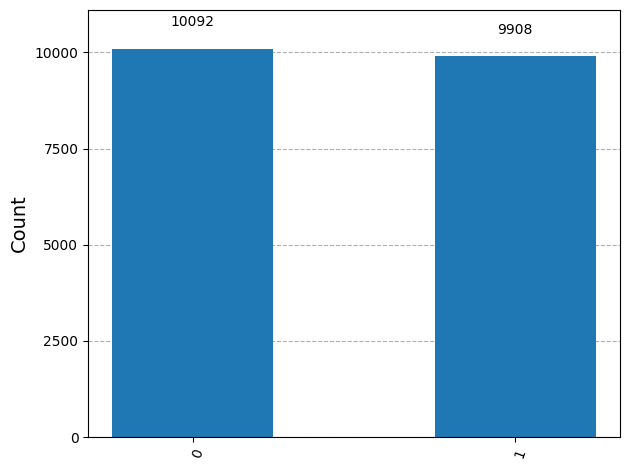

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit_aer.noise import NoiseModel, amplitude_damping_error, phase_damping_error, depolarizing_error
from qiskit.visualization import plot_histogram

backend = Aer.get_backend('aer_simulator')
p = 0.1
shots = 20000

qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)

counts_ideal = backend.run(qc, shots=shots).result().get_counts()
print("Ideal:", counts_ideal)
plot_histogram(counts_ideal)


## Answer 2: Amplitude damping

Amplitude damping: {'0': 10974, '1': 9026}


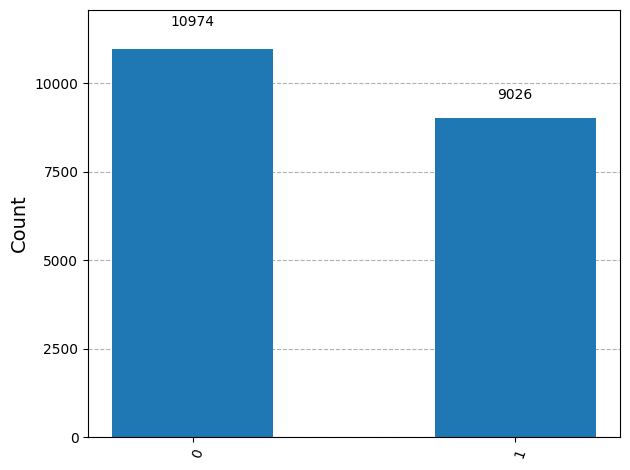

In [3]:
nm_amp = NoiseModel()
nm_amp.add_all_qubit_quantum_error(amplitude_damping_error(p), ['h'])

counts_amp = backend.run(qc, shots=shots, noise_model=nm_amp).result().get_counts()
print("Amplitude damping:", counts_amp)
plot_histogram(counts_amp)


## Answer 3: Phase damping

Phase damping: {'0': 10117, '1': 9883}


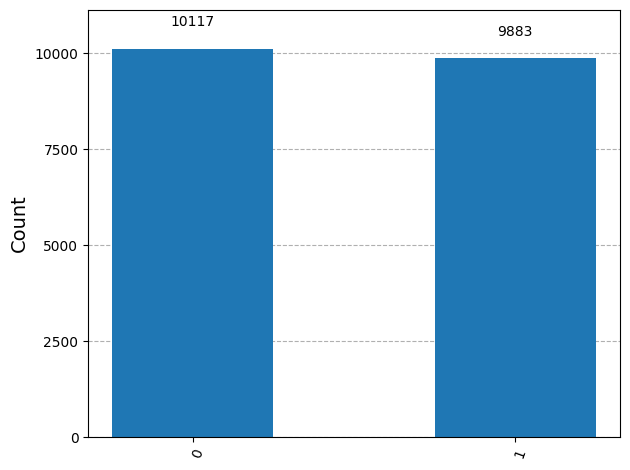

In [4]:
nm_phase = NoiseModel()
nm_phase.add_all_qubit_quantum_error(phase_damping_error(p), ['h'])

counts_phase = backend.run(qc, shots=shots, noise_model=nm_phase).result().get_counts()
print("Phase damping:", counts_phase)
plot_histogram(counts_phase)


## Answer 4: Depolarizing noise

Depolarizing: {'1': 9947, '0': 10053}


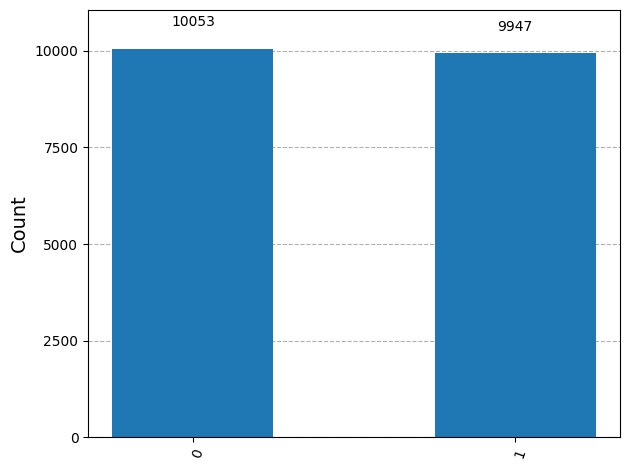

In [5]:
nm_depol = NoiseModel()
nm_depol.add_all_qubit_quantum_error(depolarizing_error(p, 1), ['h'])

counts_depol = backend.run(qc, shots=shots, noise_model=nm_depol).result().get_counts()
print("Depolarizing:", counts_depol)
plot_histogram(counts_depol)


## Interpretation

With p = 0.1 and 20000 shots, typical results look like:

- Ideal: about 50/50
- Amplitude damping: P(0) climbs to roughly 0.55, a real and visible skew toward $|0\rangle$
- Phase damping: stays at roughly 50/50
- Depolarizing: stays at roughly 50/50

**Why the difference?** Amplitude damping physically pushes population from $|1\rangle$ toward $|0\rangle$, so it changes the probability of each outcome. Phase damping only randomizes the *relative phase* between $|0\rangle$ and $|1\rangle$, and randomizing phase has no effect on how often you measure 0 versus 1 for a state that already has equal population in each (like the $|+\rangle$ state a Hadamard produces). Depolarizing noise replaces the state with the maximally mixed state some fraction of the time, which is symmetric between $|0\rangle$ and $|1\rangle$, so it adds noise (in the sense of variance) without introducing a systematic bias either way.

The takeaway: not all noise is the same, and which kind matters depends entirely on what you're measuring. A circuit that's robust to dephasing can still be very sensitive to relaxation, and vice versa.


## Extension: combining amplitude and phase damping

Combined amplitude + phase damping: {'0': 11072, '1': 8928}


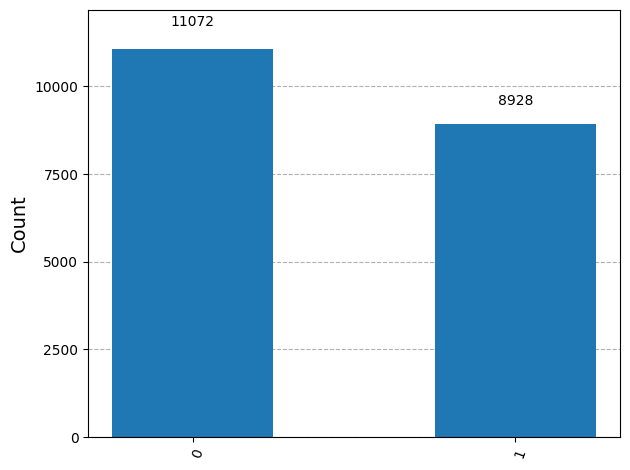

In [6]:
from qiskit_aer.noise import thermal_relaxation_error

# A simple way to combine both: compose the two error channels
combined_error = amplitude_damping_error(p).compose(phase_damping_error(p))

nm_combined = NoiseModel()
nm_combined.add_all_qubit_quantum_error(combined_error, ['h'])

counts_combined = backend.run(qc, shots=shots, noise_model=nm_combined).result().get_counts()
print("Combined amplitude + phase damping:", counts_combined)
plot_histogram(counts_combined)

# Alternative: qiskit_aer.noise.thermal_relaxation_error models T1 and T2 together
# directly from physical relaxation times, which is closer to how real hardware
# noise is usually reported (T1, T2, and gate time), if you want to explore further.
